### BUILD A BASIC CHAT BOT USING LANG-GRAPH USING (GRAPH_API)

In [1]:
from typing_extensions import TypedDict
from typing  import Annotated
from langgraph.graph import StateGraph,START , END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages : Annotated[list,add_messages]
    
graph_builder  = StateGraph(State)


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
LLM = ChatGroq(
    model = "llama-2-13b",
    temperature = 0,
    verbose=True
)
LLM

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x0000025D81A938C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025D81C386E0>, model_name='llama-2-13b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
def chatbot(state:State):
    return {
        "messages":[LLM.invoke(state["messages"])]
    }

In [6]:
## add nodes to graphs
graph_builder.add_node("chatbot",chatbot)
## add edges to graph
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph = graph_builder.compile()




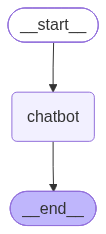

In [7]:
##visualize the graph
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke({"messages": "hello"})

NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-2-13b` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}